In [4]:
import pandas as pd

path=r'C:\Users\RSH\OneDrive\Documents\aviation_raw.xlsx'
df=pd.read_excel(path)
print(df.head())

  FlightID    Route SeatClass  SeatsSold  Revenue_USD  LoadFactor  \
0   FT-100  DXB-ZNZ   Economy        120      15000.0          75   
1   FT-101  DXB-JRO  Business         25      22000.0          80   
2   FT-102  SHJ-NBO   Economy        140      18000.0          90   
3   FT-103  DXB-ZNZ   economy         90          0.0          60   
4   FT-104  DXB-JRO   Economy        110      12000.0          85   

  BookingStatus  
0     Confirmed  
1     Confirmed  
2     Confirmed  
3     Cancelled  
4     Confirmed  


In [8]:
print(df['SeatClass'].unique())
print(df['BookingStatus'].unique())
print(f'Revenue 0 au tupu!: {(df['Revenue_USD']==0).sum()} flights')
df['SeatClass']=df['SeatClass'].str.strip().str.title()
df.loc[df['BookingStatus']== 'Cancelled','Revenue_USD']=0

<ArrowStringArray>
['Economy', 'Business', 'First']
Length: 3, dtype: str
<ArrowStringArray>
['Confirmed', 'Cancelled']
Length: 2, dtype: str
Revenue 0 au tupu!: 1 flights


In [9]:
df.groupby('Route')['Revenue_USD'].sum()

Route
DXB-JRO    81500.0
DXB-ZNZ    67500.0
SHJ-NBO    60000.0
Name: Revenue_USD, dtype: float64

In [13]:
df.groupby('Route').agg(Jumla_pesa=('Revenue_USD','sum'),
                        watu=('SeatsSold','sum'),
                        avg_Load=('LoadFactor', 'mean'))

,Jumla_pesa,watu,avg_Load
Route,,,
DXB-JRO,81500.0,358,79.800000
DXB-ZNZ,67500.0,637,78.166667
SHJ-NBO,60000.0,315,88.750000


In [14]:
import numpy as np
df['RecommendedPrice'] =np.where(df['LoadFactor']>80,df['Revenue_USD']*1.2,df['Revenue_USD'])

df[['Route', 'LoadFactor', 'Revenue_USD','RecommendedPrice']].head(10)

,Route,LoadFactor,Revenue_USD,RecommendedPrice
0,DXB-ZNZ,75,15000.0,15000.0
1,DXB-JRO,80,22000.0,22000.0
2,SHJ-NBO,90,18000.0,21600.0
3,DXB-ZNZ,60,0.0,0.0
4,DXB-JRO,85,12000.0,14400.0
5,SHJ-NBO,95,25000.0,30000.0
6,DXB-ZNZ,88,16000.0,19200.0
7,DXB-JRO,70,11000.0,11000.0
8,SHJ-NBO,78,0.0,0.0
9,DXB-ZNZ,82,15500.0,18600.0


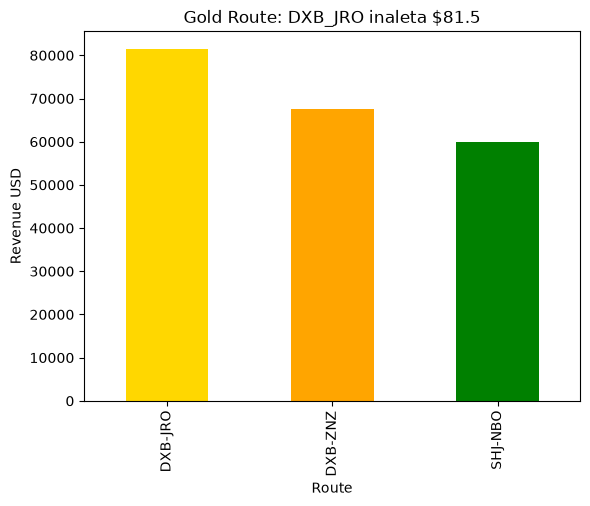

In [18]:
import matplotlib.pyplot as plt

df.groupby('Route')['Revenue_USD'].sum().plot(kind='bar', color=['gold','orange','green'])
plt.title('Gold Route: DXB_JRO inaleta $81.5')
plt.ylabel('Revenue USD')
plt.show()